# Companion notebook — Defect Classification, Lecture 3
### *Wafer Maps: Physics Beats Parameters, Until It Doesn't*

**Course:** AI for Semiconductor Manufacturing (ECE 8803-AI4) · Asif Khan, Georgia Tech
**Course website:** https://aikhan123.github.io/khan-lab-website/ai-semiconductors-course.html

This notebook reproduces Lecture 3: hand-engineered **polar features** fed to a **random
forest**, the head-to-head with the convolutional network from Lecture 2, and the
data-preparation bug that silently erased the Scratch class. Everything runs on a CPU in
under a minute. Each figure cites the slide it appears on.

**Watch / run Lecture 2 (`module 3 lecture 1.ipynb`) first.**

> Wafer-map data set: M.-J. Wu, J.-S. R. Jang, J.-L. Chen, *Wafer Map Failure Pattern
> Recognition and Similarity Ranking for Large-Scale Data Sets*, IEEE Trans. Semiconductor
> Manufacturing, 28(1), 1–12, 2015. doi:10.1109/TSM.2014.2364237

## 0 · Setup

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
NAVY="#003057"; GOLD="#B3A369"; FAIL="#E8503A"; PASS="#4A7FB5"; GOOD="#1A7A3A"; MUT="#6B7280"; BODY="#2A2E33"; GRID="#DDE2E7"
WAFER_CMAP = ListedColormap(["#1a1a1a", PASS, FAIL])

DATA = "wm811k_dev.npz"
d = np.load(DATA, allow_pickle=True)
X, y, lot = d["X"], d["y"].astype(str), d["lot"].astype(str)
CLASSES = ["none","Edge-Ring","Edge-Loc","Center","Loc","Scratch","Random","Donut","Near-full"]
def show_wafer(ax,w,t=""): ax.imshow(w,cmap=WAFER_CMAP,vmin=0,vmax=2,interpolation="nearest"); ax.set_title(t,fontsize=10); ax.set_xticks([]); ax.set_yticks([])
print(f"{len(X):,} wafers loaded")

25,956 wafers loaded


## 1 · Polar features  (Part 2 · Section 1)

*Slides "The idea: measure failures in polar coordinates" and "28 features, in a few
lines."* The hypothesis is that wafer defects are **radially structured**, so we describe
each wafer by *where its failures sit in polar coordinates* rather than by raw pixels:

* **10 radial bins** — fraction of dies that failed in each annulus (centre → edge)
* **12 angular bins** — fraction that failed in each wedge (0 … 2π)
* **6 summary statistics** — overall fail fraction, mean & spread of failure radius,
  centre-to-edge contrast, angular concentration, log fail count

= **28 numbers per wafer**, every one physically interpretable.

In [2]:
# ---- geometry, computed once for the 64x64 grid ----------------------------
H = W = 64
cy = cx = (H-1)/2
yy, xx = np.mgrid[0:H, 0:W]
R = np.sqrt((yy-cy)**2 + (xx-cx)**2) / 31.5           # 0 at centre → ~1 at edge
R = np.clip(R, 0, 1)
TH = (np.arctan2(yy-cy, xx-cx) + np.pi) / (2*np.pi)   # 0 … 1
rbin = np.clip((R*10).astype(int), 0, 9).ravel()
tbin = np.clip((TH*12).astype(int), 0, 11).ravel()
Rf = R.ravel()

def polar_features(Xint):
    N = len(Xint); flat = Xint.reshape(N, -1)
    die = flat > 0; fail = flat == 2
    F = np.zeros((N, 28), dtype="float32")
    for b in range(10):                                # radial
        m = rbin == b
        F[:, b] = fail[:, m].sum(1) / np.maximum(die[:, m].sum(1), 1)
    for b in range(12):                                # angular
        m = tbin == b
        F[:, 10+b] = fail[:, m].sum(1) / np.maximum(die[:, m].sum(1), 1)
    dc, fc = die.sum(1), fail.sum(1)                   # 6 summaries
    F[:, 22] = fc / np.maximum(dc, 1)                                  # overall fail fraction
    F[:, 23] = (fail*Rf).sum(1) / np.maximum(fc, 1)                    # mean failure radius
    F[:, 24] = np.sqrt(np.maximum((fail*Rf**2).sum(1)/np.maximum(fc,1) - F[:,23]**2, 0)) # radius spread
    F[:, 25] = F[:, 9] - F[:, 0]                                       # edge-minus-centre contrast
    F[:, 26] = F[:, 10:22].max(1) - F[:, 10:22].mean(1)                # angular concentration
    F[:, 27] = np.log1p(fc)                                            # log fail count
    return F

FEAT = polar_features(X)
FEAT_NAMES = [f"r{b}" for b in range(10)] + [f"a{b}" for b in range(12)] + \
             ["fail_frac","mean_radius","radius_spread","edge_contrast","ang_concentration","log_nfail"]
print("feature matrix:", FEAT.shape)

feature matrix: (25956, 28)


### Figure — the hypothesis, visualized
*Slide "The hypothesis, visualized."* The mean radial failure profile per class. Center
peaks near r = 0, Donut at mid-radius, Edge-Ring near the edge — each has a separable
signature. **Scratch is nearly flat: a thin line has no radial profile,** so the feature
set is blind to it. This predicts the collapse we are about to see.

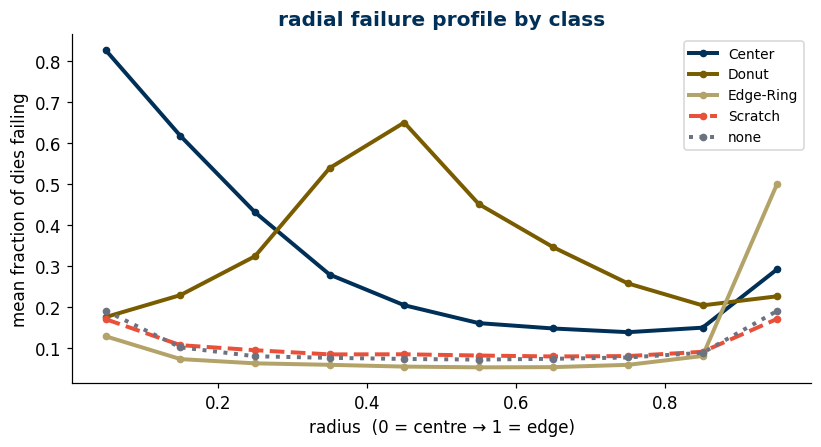

In [3]:
fig, ax = plt.subplots(figsize=(7.6,4.2))
bins = np.linspace(0.05,0.95,10)
styles = {"Center":(NAVY,"-"),"Donut":("#7A5C00","-"),"Edge-Ring":(GOLD,"-"),
          "Scratch":(FAIL,"--"),"none":(MUT,":")}
for c,(col,ls) in styles.items():
    prof = FEAT[y==c, 0:10].mean(0)
    ax.plot(bins, prof, color=col, ls=ls, lw=2.6, marker="o", ms=4, label=c)
ax.set_xlabel("radius  (0 = centre → 1 = edge)"); ax.set_ylabel("mean fraction of dies failing")
ax.set_title("radial failure profile by class", color=NAVY, fontweight="bold"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 2 · Polar features + random forest  (Part 2 · Section 1)

*Slide "Polar features + random forest."* Feed the 28 features to a 300-tree random forest,
split by lot as before. It is fast, accurate, and fully interpretable.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

tr, te = next(GroupShuffleSplit(1, test_size=0.25, random_state=0).split(FEAT, y, groups=lot))
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                            n_jobs=-1, random_state=0).fit(FEAT[tr], y[tr])
p_rf = rf.predict(FEAT[te])
print(f"Polar + RF (dev split) · accuracy {accuracy_score(y[te],p_rf):.3f} · macro-F1 {f1_score(y[te],p_rf,average='macro'):.3f}")

P,Rc,Fs,S = precision_recall_fscore_support(y[te], p_rf, labels=CLASSES, zero_division=0)
pd.DataFrame({"Precision":P.round(3),"Recall":Rc.round(3),"F1":Fs.round(3),"n":S}, index=CLASSES)

Polar + RF (dev split) · accuracy 0.939 · macro-F1 0.630


,Precision,Recall,F1,n
none,0.939,0.998,0.968,5283
Edge-Ring,0.965,0.927,0.946,301
Edge-Loc,0.859,0.332,0.478,184
Center,0.952,0.702,0.808,168
Loc,0.973,0.254,0.402,142
Scratch,0.000,0.000,0.000,53
Random,0.500,0.455,0.476,11
Donut,0.917,0.647,0.759,17
Near-full,0.833,0.833,0.833,6


### Figure — what the forest actually used
*Slide "What the forest actually used."* Feature importances — unlike a conv filter, every
bar has a physical meaning you can read off. The radial bins and radius statistics
dominate, exactly as the hypothesis predicted.

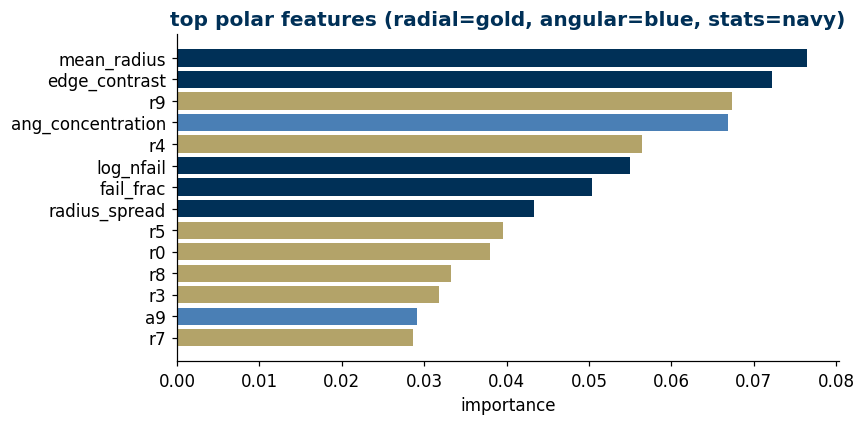

In [5]:
imp = rf.feature_importances_
order = np.argsort(imp)[::-1][:14]
fig, ax = plt.subplots(figsize=(8,4))
cols = [GOLD if FEAT_NAMES[i].startswith("r") and FEAT_NAMES[i][1:].isdigit() else
        (PASS if FEAT_NAMES[i].startswith("a") else NAVY) for i in order]
ax.barh([FEAT_NAMES[i] for i in order][::-1], imp[order][::-1], color=cols[::-1])
ax.set_xlabel("importance"); ax.set_title("top polar features (radial=gold, angular=blue, stats=navy)",
             color=NAVY, fontweight="bold")
plt.tight_layout(); plt.show()

### Figure — perfect, and useless: the Scratch collapse
*Slides "Perfect, and useless" and "The assumption that broke."* Scratch is the one class
the radial features cannot see. Its F1 sits near the floor while radially-structured
classes score well — precisely because a straight scratch has no radial signature.

/tmp/ipykernel_1910/295320411.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_ylabel("F1 (dev split)"); ax.set_ylim(0,1); ax.set_xticklabels([CLASSES[i] for i in order2], rotation=20, ha="right")


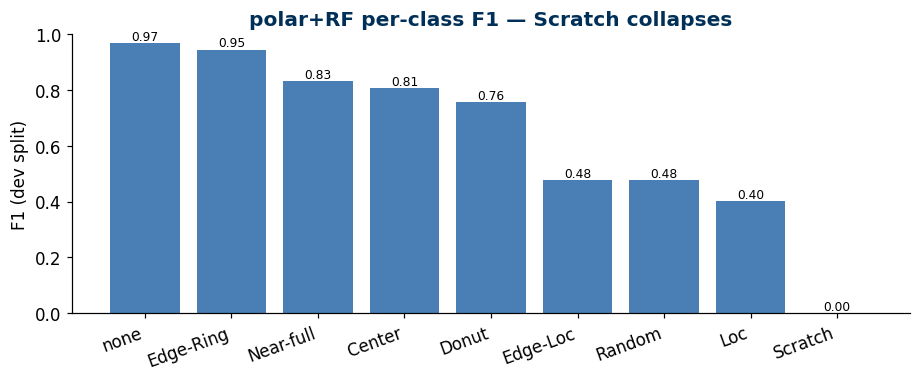

In [6]:
fig, ax = plt.subplots(figsize=(8.5,3.6))
order2 = np.argsort(Fs)[::-1]
bars = ax.bar([CLASSES[i] for i in order2], Fs[order2],
              color=[FAIL if CLASSES[i]=="Scratch" else PASS for i in order2])
for b,i in zip(bars,order2): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{Fs[i]:.2f}", ha="center", fontsize=8)
ax.set_ylabel("F1 (dev split)"); ax.set_ylim(0,1); ax.set_xticklabels([CLASSES[i] for i in order2], rotation=20, ha="right")
ax.set_title("polar+RF per-class F1 — Scratch collapses", color=NAVY, fontweight="bold")
plt.tight_layout(); plt.show()

## 3 · Head-to-head with the CNN, and the scoreboard  (Part 2 · Section 2)

*Slides "CNN vs polar features, class by class" and "The full scoreboard."* The CNN was
trained in Lecture 2 (GPU); here we use the lecture's reported **full-test-set** numbers so
the comparison is on one footing. The two models track closely — except on Scratch, where
the CNN's learned spatial filters win decisively (0.557 vs 0.037).

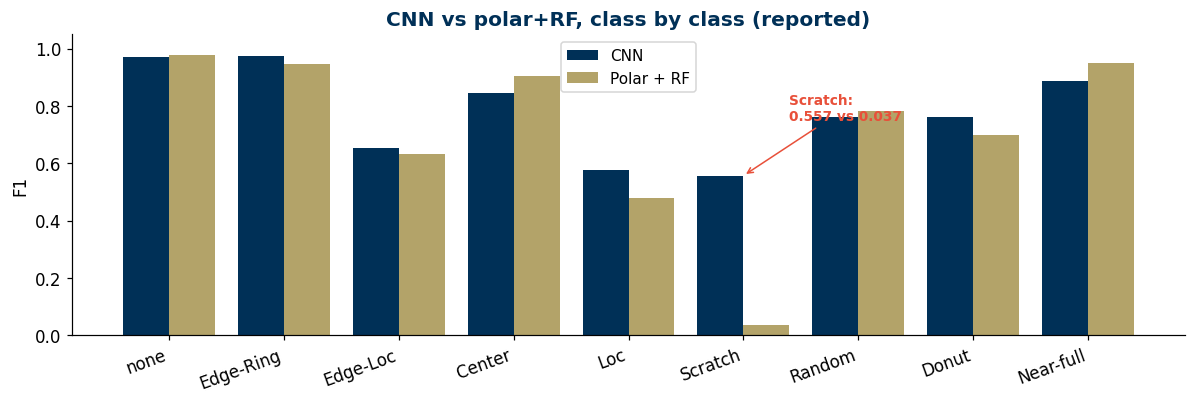

In [7]:
cats = ["none","Edge-Ring","Edge-Loc","Center","Loc","Scratch","Random","Donut","Near-full"]
cnn  = [0.970,0.975,0.655,0.845,0.578,0.557,0.762,0.761,0.889]   # reported, full test set
rfF  = [0.977,0.948,0.631,0.904,0.480,0.037,0.783,0.700,0.952]   # reported, full test set
fig, ax = plt.subplots(figsize=(11,3.8)); xx=np.arange(len(cats)); w=0.4
ax.bar(xx-w/2, cnn, w, label="CNN", color=NAVY)
ax.bar(xx+w/2, rfF, w, label="Polar + RF", color=GOLD)
ax.annotate("Scratch:\n0.557 vs 0.037", (5, 0.557), (5.4, 0.75), color=FAIL, fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=FAIL))
ax.set_xticks(xx); ax.set_xticklabels(cats, rotation=20, ha="right"); ax.set_ylim(0,1.05)
ax.set_ylabel("F1"); ax.legend(fontsize=10); ax.set_title("CNN vs polar+RF, class by class (reported)", color=NAVY, fontweight="bold")
plt.tight_layout(); plt.show()

In [8]:
board = pd.DataFrame([
    ["Majority baseline",   0.854, 0.10,  0.000, "everything"],
    ["Logistic regression", 0.688, 0.473, 0.053, "variable position"],
    ["Deep neural net †",   0.818, 0.437, 0.048, "position (same as LR)"],
    ["CNN",                 0.939, 0.777, 0.557, "ambiguous classes"],
    ["Polar + RF",          0.952, 0.712, 0.037, "non-radial (Scratch)"],
], columns=["Model","Accuracy","Macro-F1","Scratch F1","Breaks on"])
print("† deep-net row on the dev subset; other rows full test set.")
print("Best accuracy (Polar+RF) and best macro-F1 (CNN) belong to different models.")
board

† deep-net row on the dev subset; other rows full test set.
Best accuracy (Polar+RF) and best macro-F1 (CNN) belong to different models.


,Model,Accuracy,Macro-F1,Scratch F1,Breaks on
0,Majority baseline,0.854,0.100,0.000,everything
1,Logistic regression,0.688,0.473,0.053,variable position
2,Deep neural net †,0.818,0.437,0.048,position (same as LR)
3,CNN,0.939,0.777,0.557,ambiguous classes
4,Polar + RF,0.952,0.712,0.037,non-radial (Scratch)


## 4 · The preprocessing bug  (Part 2 · Section 3)

*Slides "How a downsampling choice erased Scratch" and "Invisible in aggregate, fatal in
the tail."* Wafer maps are downsampled before modelling. **How** you downsample decides
whether a one-die-wide scratch survives:

* **Subsampling** keeps every k-th row and column — a thin line falls through the gaps.
* **Max-pooling** marks a block as failing if *any* die in it failed — thin features survive.

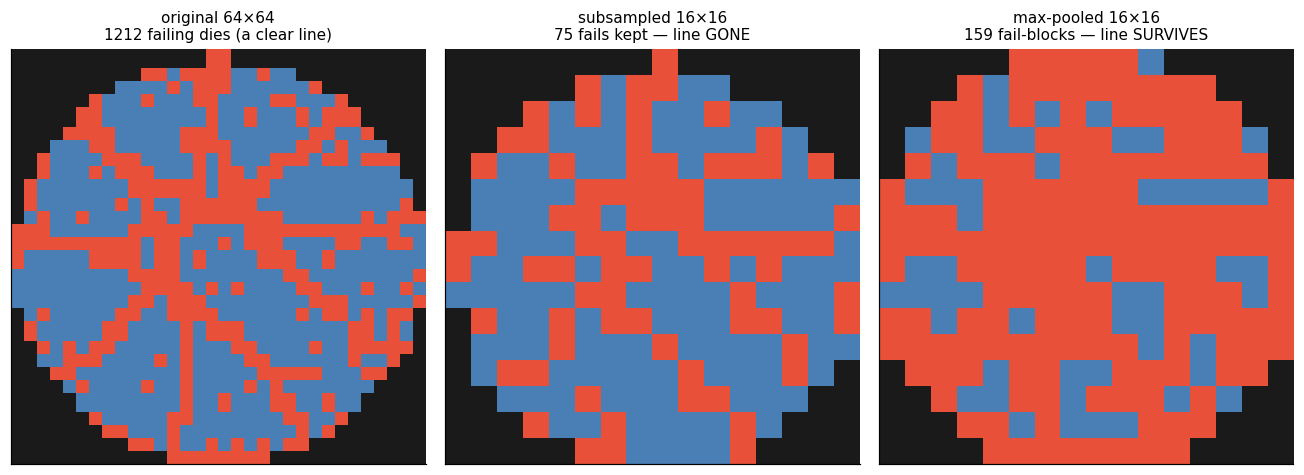

subsampling kept 75/1212 failing dies (6%); max-pool marked 159 blocks failing.


In [9]:
# pick the scratch wafer with the clearest line (most failing dies)
sc_idx = np.where(y=="Scratch")[0]
sc = sc_idx[np.argmax([(X[i]==2).sum() for i in sc_idx])]
w = X[sc]

def subsample(w, k=4): return w[::k, ::k]
def maxpool_cat(w, k=4):
    Hh,Ww = w.shape; out = np.zeros((Hh//k, Ww//k), int)
    for i in range(Hh//k):
        for j in range(Ww//k):
            blk = w[i*k:(i+1)*k, j*k:(j+1)*k]
            out[i,j] = 2 if (blk==2).any() else (1 if (blk==1).any() else 0)
    return out

sub, mp = subsample(w), maxpool_cat(w)
orig_fail = int((w==2).sum())
keep_sub  = int((sub==2).sum())
keep_mp   = int((mp==2).sum())

fig, ax = plt.subplots(1,3, figsize=(12,4.2))
show_wafer(ax[0], w,  f"original 64×64\n{orig_fail} failing dies (a clear line)")
show_wafer(ax[1], sub, f"subsampled 16×16\n{keep_sub} fails kept — line GONE")
show_wafer(ax[2], mp,  f"max-pooled 16×16\n{keep_mp} fail-blocks — line SURVIVES")
plt.tight_layout(); plt.show()
print(f"subsampling kept {keep_sub}/{orig_fail} failing dies ({keep_sub/orig_fail*100:.0f}%);"
      f" max-pool marked {keep_mp} blocks failing.")

The lesson (*"Invisible in aggregate, fatal in the tail"*): this choice barely moves overall
accuracy — Scratch is 0.7% of the data — but it is the difference between detecting scratches
and never seeing them. A metric that looks fine in aggregate can be fatal in the rare-class
tail, which is exactly what **macro-F1** is designed to expose.

## 5 · The advanced landscape  (Part 2 · Section 4)

*Slides "Closing the polar blind spot" through "One idea, five times."* The methods a
working group reaches for next, each one relaxing an assumption an earlier model made:

* **Close the polar blind spot** — add features (or a branch) that can see thin, oriented
  structures, so Scratch stops being invisible.
* **Physically valid augmentation** — rotate/reflect wafers (the physics is rotation-
  symmetric) to manufacture labels for the rare classes.
* **Reshape the loss / invert the problem** — focal or class-balanced losses; or treat rare
  patterns as anomalies rather than a 9-way classification.
* **Self-supervised pretraining** — learn representations from the ~800K *unlabelled* WM-811K
  wafers, then fine-tune on the few labelled ones.
* **Vision foundation models** — with the caveat that natural-image pretraining transfers
  imperfectly to categorical wafer maps.

### The through-line of the whole module

Every model encodes an assumption about the physics, and its failures tell you which
assumption broke:

| Model | Assumption | Breaks on |
|---|---|---|
| Logistic regression | pixels are independent features | position varies (Loc, Scratch) |
| Deep neural net | depth & width, not spatial structure | position still varies (like LR) |
| CNN | locality + translation invariance | precision on ambiguous classes |
| Polar + RF | patterns are radially symmetric | a line has no radial signature |
| Advanced methods | each relaxes a prior assumption | the moving frontier |

That single idea — *its failures tell you which assumption broke* — is the whole unit.